In [1]:
import sys
import os
working_path = './stat_csv'
sys.path.append(working_path)
os.chdir(working_path)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 21.4 MB/s  0:00:00.5 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 23.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 23.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 25.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 24.9 MB/s  0:00:35 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 23.6 MB/s  0:00:0023.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 23.4 MB/s  0:00:23 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 30.1 MB/s  0:00:0030.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 29.0 MB/s  0:00:03 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 22.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 17.9 MB/s  0:00:34 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━

### Download Dataset

In [4]:
from sklearn.datasets import fetch_20newsgroups

# Load dataset
data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes')
)

texts = data.data
labels = data.target

print("Number of documents:", len(texts))
print("Example document:\n", texts[0][:500])

Number of documents: 18846
Example document:
 

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a


In [5]:
for i, category in enumerate(data.target_names):
    print(i, category)

0 alt.atheism
1 comp.graphics
2 comp.os.ms-windows.misc
3 comp.sys.ibm.pc.hardware
4 comp.sys.mac.hardware
5 comp.windows.x
6 misc.forsale
7 rec.autos
8 rec.motorcycles
9 rec.sport.baseball
10 rec.sport.hockey
11 sci.crypt
12 sci.electronics
13 sci.med
14 sci.space
15 soc.religion.christian
16 talk.politics.guns
17 talk.politics.mideast
18 talk.politics.misc
19 talk.religion.misc


### Convert to Bert Embeddings

In [6]:
from sentence_transformers import SentenceTransformer

# Load BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')

# To make it faster for demo
texts_subset = texts[:2000]

# Convert text to embeddings
embeddings = model.encode(texts_subset, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


### Clustering Using Bert Embeddings

In [7]:
from sklearn.cluster import KMeans

n_clusters = 20

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings)

print(clusters[:10])

[ 4  0 15 11  0 11 12  4  4  1]


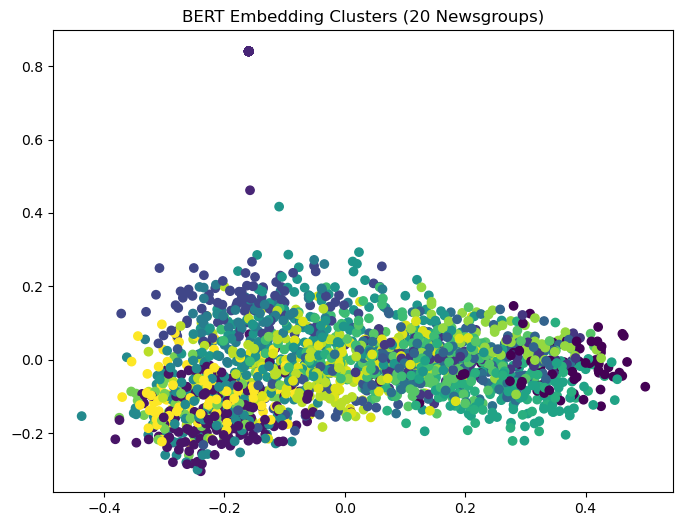

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=clusters)
plt.title("BERT Embedding Clusters (20 Newsgroups)")
plt.show()

In [9]:
cluster_id = 0

for i, text in enumerate(texts_subset):
    if clusters[i] == cluster_id:
        print(text[:200])
        print("------")

My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:

  - Diamond Stealth Pro Local Bus

  - Orchid Farenh
------
1)    I have an old Jasmine drive which I cannot use with my new system.
 My understanding is that I have to upsate the driver with a more modern
one in order to gain compatability with system 7.0.1. 
------
CAD Setup For Sale:

G486PLB Local Bus Motherboard
  Can use up to 32MB of SIMMS (256k/1M/4M)
  9 expansion slots (8 16-bit slots, 1 32-bit slot)
  Weitek 4167 co-processor socket

33 Mhz Intel CPU

3
------
Is there a way to connect a PowerBook 145, Mac IIsi, and Personal LaserWriter
LS so that I can (not necessarily silmultaneoulsy) print from either the IIsi,
or PB, and file share between the IIsi and 
------
Hi netlanders,

Does anybody know if there is something like Macintosh Hypercard for any UNIX 
platform?


Thanks in advance

------
A friend and I have ATI Graphic Ult

In [10]:
cluster_id = 1

for i, text in enumerate(texts_subset):
    if clusters[i] == cluster_id:
        print(text[:200])
        print("------")


If a Christian means someone who believes in the divinity of Jesus, it is safe
to say that Jesus was a Christian.
--
"On the first day after Christmas my truelove served to me...  Leftover Turkey!
On
------
930418

Do what thou wilt shall be the whole of the Law. [Honestly.]
The word of Sin is Restriction. [Would I kid you?]


Does one man's words encompass the majestic vision of thousands
of individuals
------


Oh, Bobby. You're priceless. Did I ever tell you that?

My policy with Bobby's posts, should anyone give a damn, is to flick
through the thread at high speed, searching for posts of Bobby's which
ha
------
Let the word of Christ dwell in you richly as you teach and admonish one
another with all wisdom, and as you sing psalms, hymns and spiritual songs with
gratitude in your hearts to God. 
Colossians 3:
------


First of all, "ceremonial law" is an extraScriptural term.  It is sometimes
used as a framework to view Scripture.  But if you look at Collosions,
without going into 